In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_HERE = Path.cwd()
_ROOT = _HERE.parent if _HERE.name == "EDA" else _HERE
_EDA  = _ROOT / "EDA"
for _p in (str(_ROOT), str(_EDA)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

from config import DATA_DIR, PATHS, PARAMS, EDA_RDA_DIR
from analysis.pipeline import DataAnalysisPipeline
from analysis.plot_pca_rda import (
    plot_hc_variance_and_heatmap,
    plot_hc_pca_grid,
    plot_normalization_unique_r2_summary,
)
from viz_style import apply_style
apply_style()

In [3]:
adata = sc.read_h5ad(PATHS["merged_qc"])
adata = adata[adata.obs["QC_Passed"] == True]

combined_metrics = [
    "log(Total Reads)", "Spliced Reads (%)", "gDNA Contamination (Intron/Exon)",
    "rRNA Fraction", "RNA Degradation (3' Bias)", "Platelet Score",
    "GC Bias", "Gene Length Bias", "NG80", "NP80", "(NP80/NG80)",
    "Sample Volume (mL)", "Total Centrifugation Force (g)",
]

### RDA-based Variance Decomposition

In [4]:
# Ibarra et al. is excluded from RDA and bias~phenotype analyses because their
# study design is not a normal-vs-disease comparison: phenotype and batch are
# fully confounded by design, making variance decomposition results uninterpretable.
EXCLUDE_FROM_PHENOTYPE_ANALYSIS = ["Ibarra et al."]

adata_rda = adata[~adata.obs["Author"].isin(EXCLUDE_FROM_PHENOTYPE_ANALYSIS)].copy()
pipeline_rda = DataAnalysisPipeline(
    adata=adata_rda,
    bias_metrics_df=None,
    phenotype_col='Phenotype_Processed',
    batch_col='Batch_ID',
    analysis_metrics=combined_metrics,
    min_samples_per_study=75
)
pipeline_rda.set_layer('CPM_log1p')

--- [Init] Preparing Metadata ---
   Valid studies (>= 75): 9
   [Skip] Too few samples: ['Tuni et al.', 'Reggiardo et al.', 'Raissadati et al.', 'Block et al.', 'Peddu\xa0et al.']


--- Layer: switching to 'CPM_log1p' ---



--- [Analysis] Partial RDA Variance Decomposition per Study ---


   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


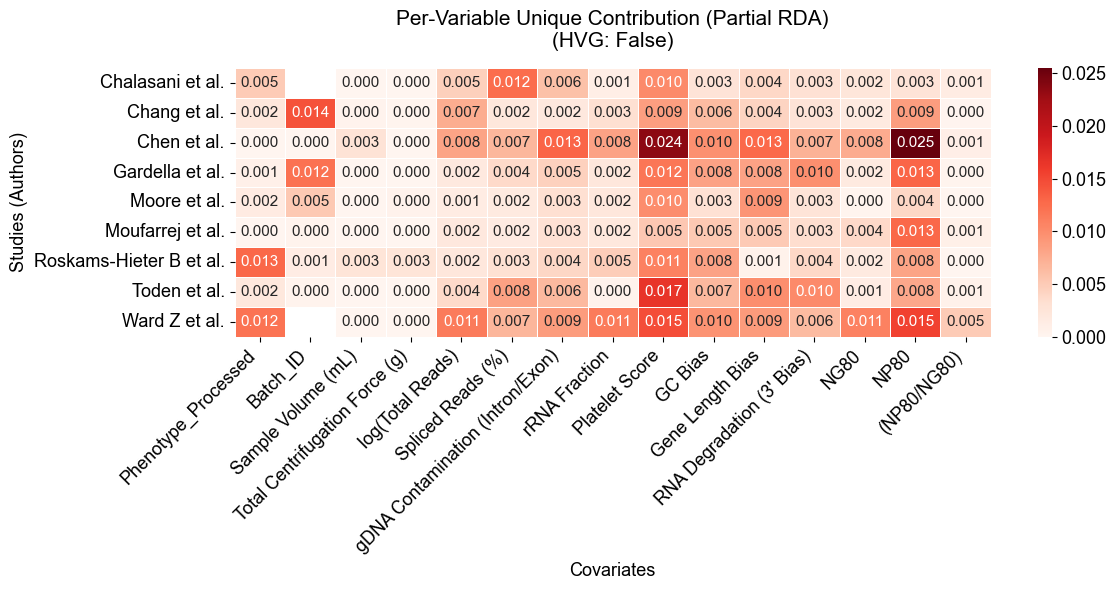

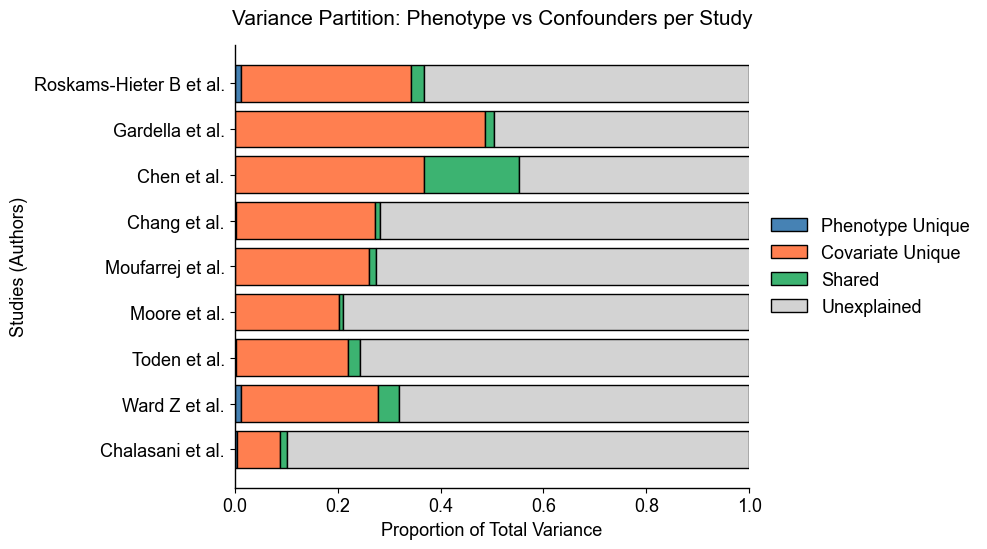


--- [Analysis] Partial RDA Variance Decomposition per Study ---


   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


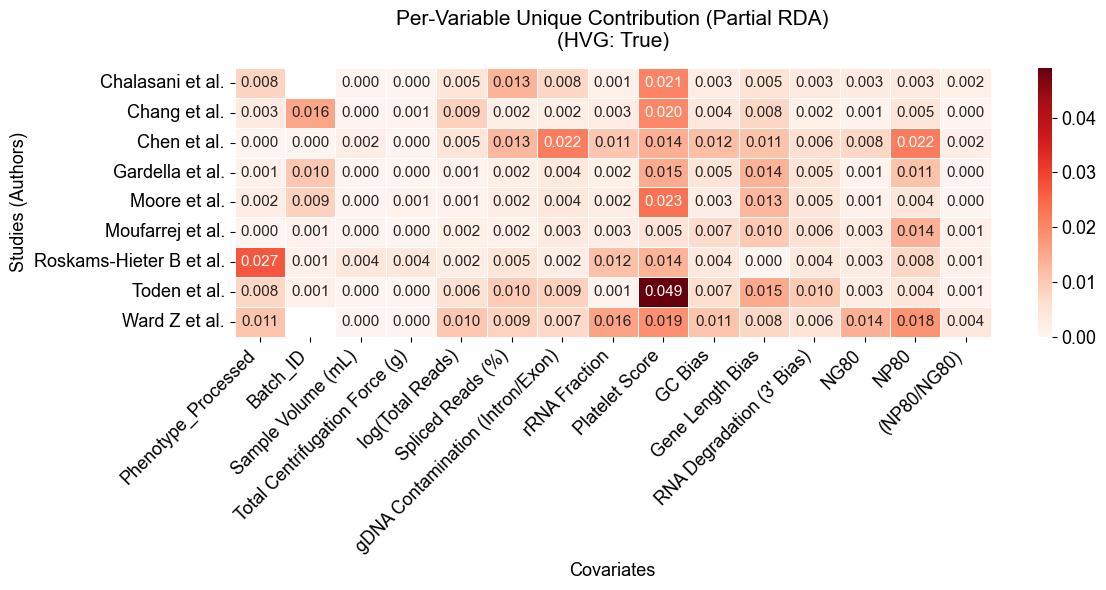

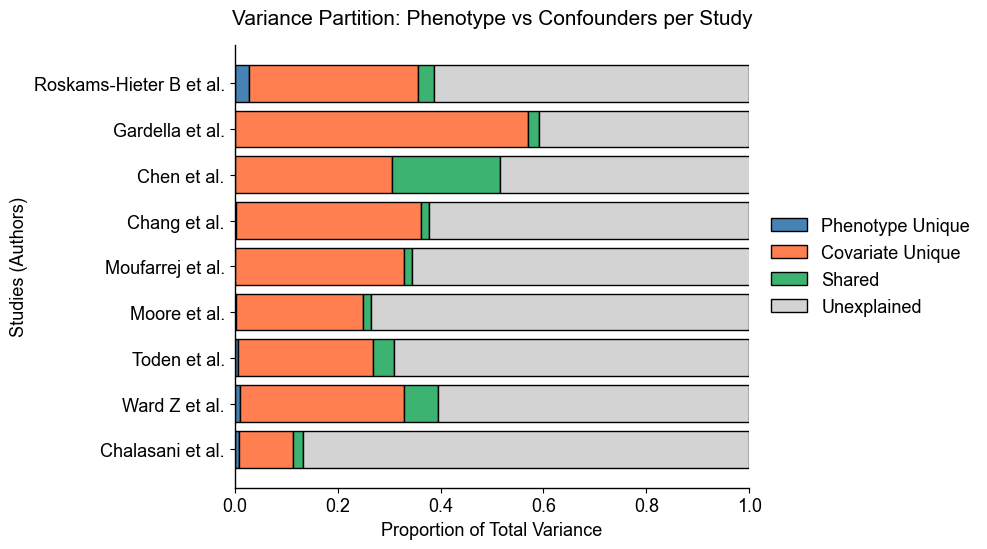

In [5]:
custom_x_order = [
    'Phenotype_Processed', 
    'Batch_ID', 
    'Sample Volume (mL)', 
    'Total Centrifugation Force (g)',
    'log(Total Reads)', 
    'Spliced Reads (%)', 
    'gDNA Contamination (Intron/Exon)', 
    'rRNA Fraction', 
    'Platelet Score', 
    'GC Bias', 
    'Gene Length Bias', 
    "RNA Degradation (3' Bias)", 
    'NG80', 
    'NP80', 
    '(NP80/NG80)'
]

rda_vars = custom_x_order 
rda_results_no_hvg = pipeline_rda.analyze_partial_rda_per_study(
    vars=rda_vars,
    use_hvg=False,
    customized_x_order=custom_x_order, save_dir=None  # was "./Analysis_Results/RDA/NoHVG/"
)
rda_results_hvg = pipeline_rda.analyze_partial_rda_per_study(
    vars=rda_vars,
    use_hvg=True,
    customized_x_order=custom_x_order, save_dir=None  # was "./Analysis_Results/RDA/HVG/"
)

### Cascade Correction RDA


--- [Analysis] Sequential Partial RDA (One-by-One Cascade) ---


   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


...

   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 uni

   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.
   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


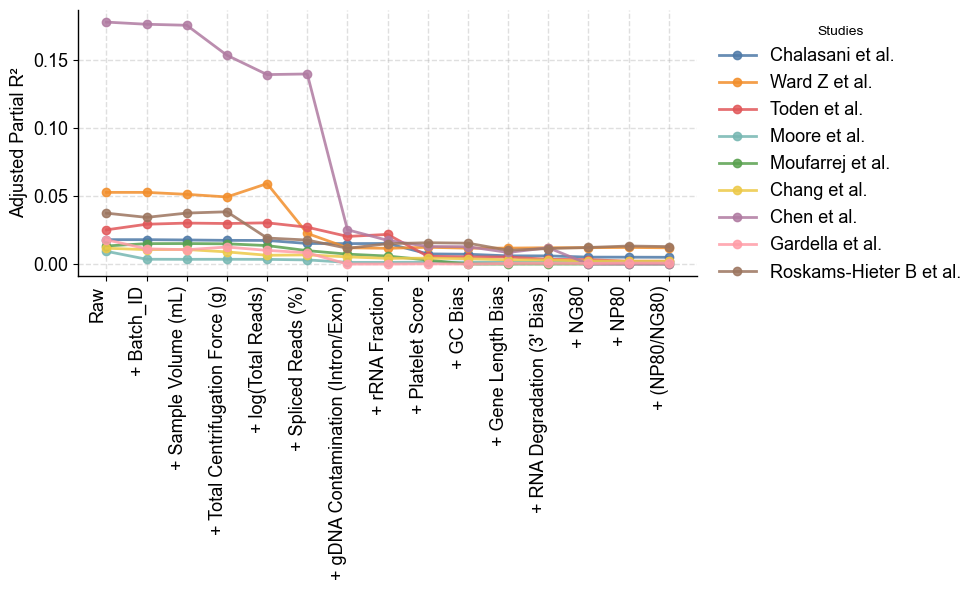

In [6]:
cascade_results = pipeline_rda.run_cascade_rda_per_study(
    vars=rda_vars,
    phenotype_var='Phenotype_Processed',
    batch_var='Batch_ID',
    show_plots=True,
    save_path=None  # was "./Analysis_Results/RDA/rda_cascade_results.png"
)


--- [Analysis] Normalization Comparison (Partial RDA) per Study ---
 > Chalasani et al.


   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


   [Warning] 'Batch_ID' has only 1 unique level after encoding — skipped.


...

 > Moufarrej et al.


 > Chang et al.


 > Chen et al.


 > Gardella et al.


 > Roskams-Hieter B et al.


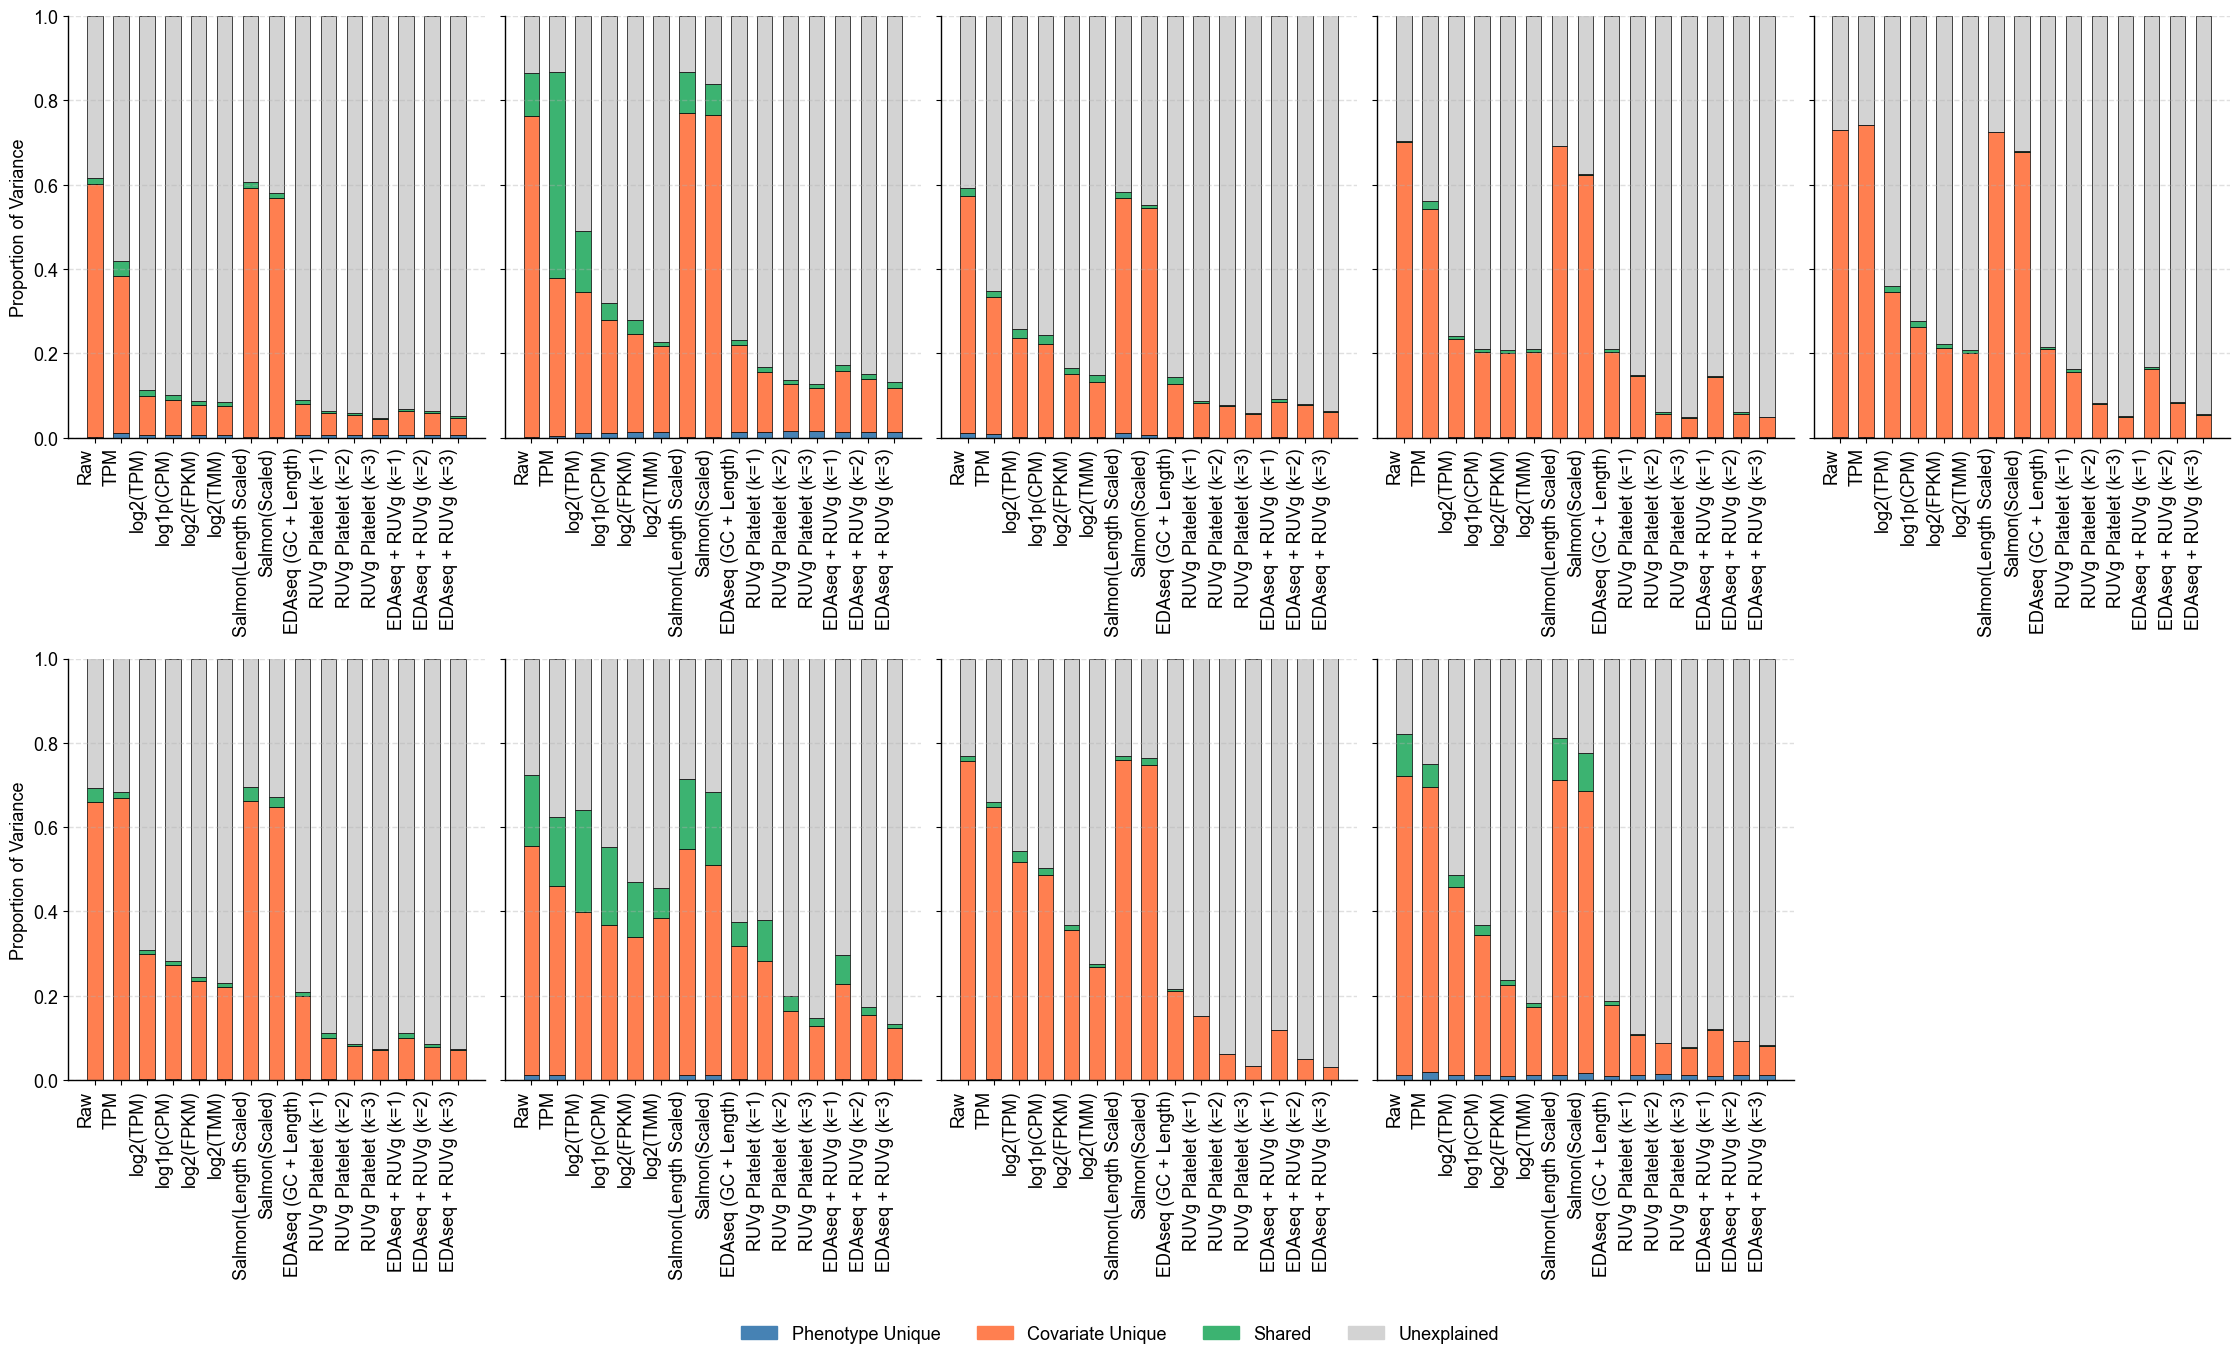

In [7]:
bias_metrics = combined_metrics
norm_results = pipeline_rda.analyze_normalization_rda(
    vars=rda_vars, show_plots=True, phenotype_var='Phenotype_Processed', batch_var='Batch_ID', save_path=None  # was "Analysis_Results/RDA/rda_normalization_results.png"
)

In [13]:
RDA_DIR = EDA_RDA_DIR
UNIQUE_CACHE = RDA_DIR / "rda_normalization_r2_results.tsv"

if not UNIQUE_CACHE.is_file():
    norm_results["unique_contributions"].to_csv(UNIQUE_CACHE, sep="\t")


In [14]:
print(norm_results["unique_contributions"])
print(norm_results["variance_partition"])
print(norm_results["r2_summary"])

NameError: name 'norm_results' is not defined

In [15]:
layer_mean = (pd.read_csv("./Analysis_Results/RDA/rda_normalization_r2_results.tsv", sep="\t")
              .groupby("Layer").mean(numeric_only=True))
bias_cols = [c for c in layer_mean.columns if c not in ("Phenotype_Processed", "Batch_ID")]

# Raw / Salmon layers are not depth-normalised, so their bias R2 is dominated by
# log(Total Reads) alone. log1p(CPM) is the baseline quoted downstream.
norm_summary = pd.DataFrame({
    "phenotype_R2": layer_mean["Phenotype_Processed"],
    "bias_R2_sum": layer_mean[bias_cols].sum(axis=1),
    "depth_R2": layer_mean["log(Total Reads)"],
    "batch_R2": layer_mean["Batch_ID"],
})
norm_summary["bias_over_phenotype"] = norm_summary["bias_R2_sum"] / norm_summary["phenotype_R2"]
norm_summary["bias_excl_depth_over_phenotype"] = (
    (norm_summary["bias_R2_sum"] - norm_summary["depth_R2"]) / norm_summary["phenotype_R2"]
)
# norm_summary.to_csv("./Analysis_Results/RDA/rda_normalization_layer_summary.tsv", sep="\t")
norm_summary.sort_values("bias_R2_sum", ascending=False).round(4)

,phenotype_R2,bias_R2_sum,depth_R2,batch_R2,bias_over_phenotype,bias_excl_depth_over_phenotype
Layer,,,,,,
Raw,0.0042,0.2697,0.1803,0.0115,64.0748,21.2315
Salmon(Length Scaled),0.0043,0.2679,0.1793,0.0114,63.0064,20.8246
Salmon(Scaled),0.0040,0.2508,0.1639,0.0100,62.9153,21.7954
TPM,0.0066,0.1558,0.0080,0.0147,23.6669,22.4558
log1p(CPM),0.0040,0.0677,0.0048,0.0048,16.8015,15.6168
log2(TMM),0.0037,0.0643,0.0062,0.0045,17.1684,15.5121
log2(TPM),0.0037,0.0641,0.0039,0.0047,17.5460,16.4859
log2(FPKM),0.0035,0.0633,0.0053,0.0044,17.8570,16.3559
RUVg Platelet (k=1),0.0041,0.0625,0.0061,0.0051,15.3273,13.8220


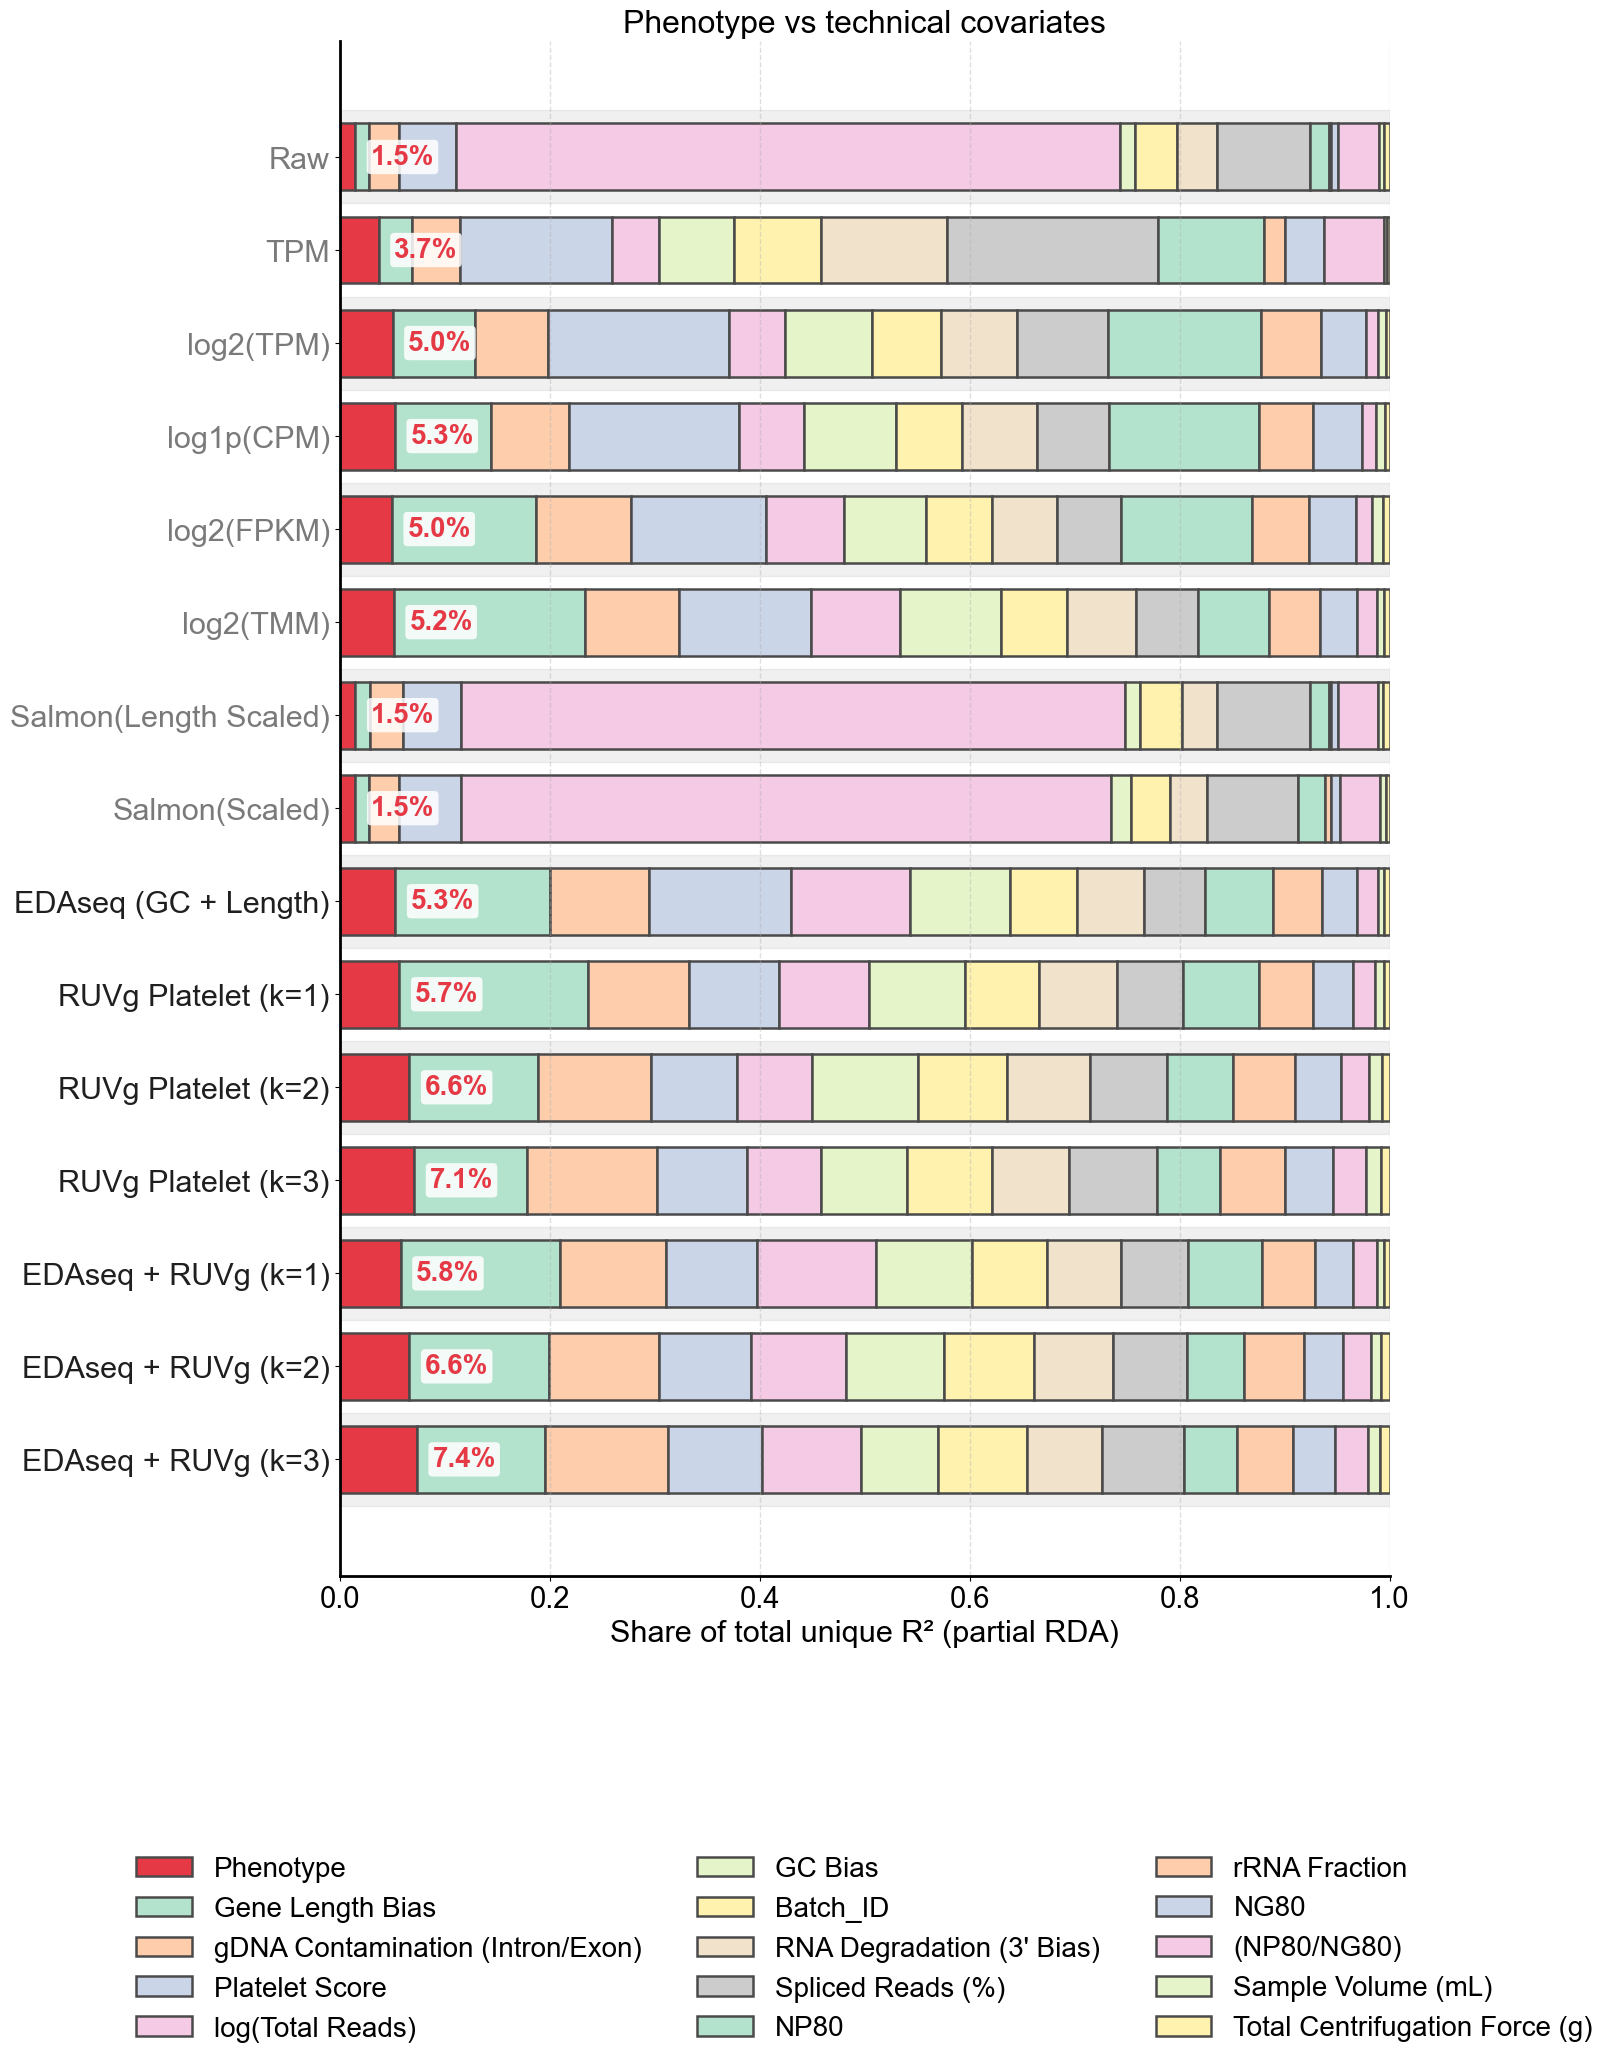

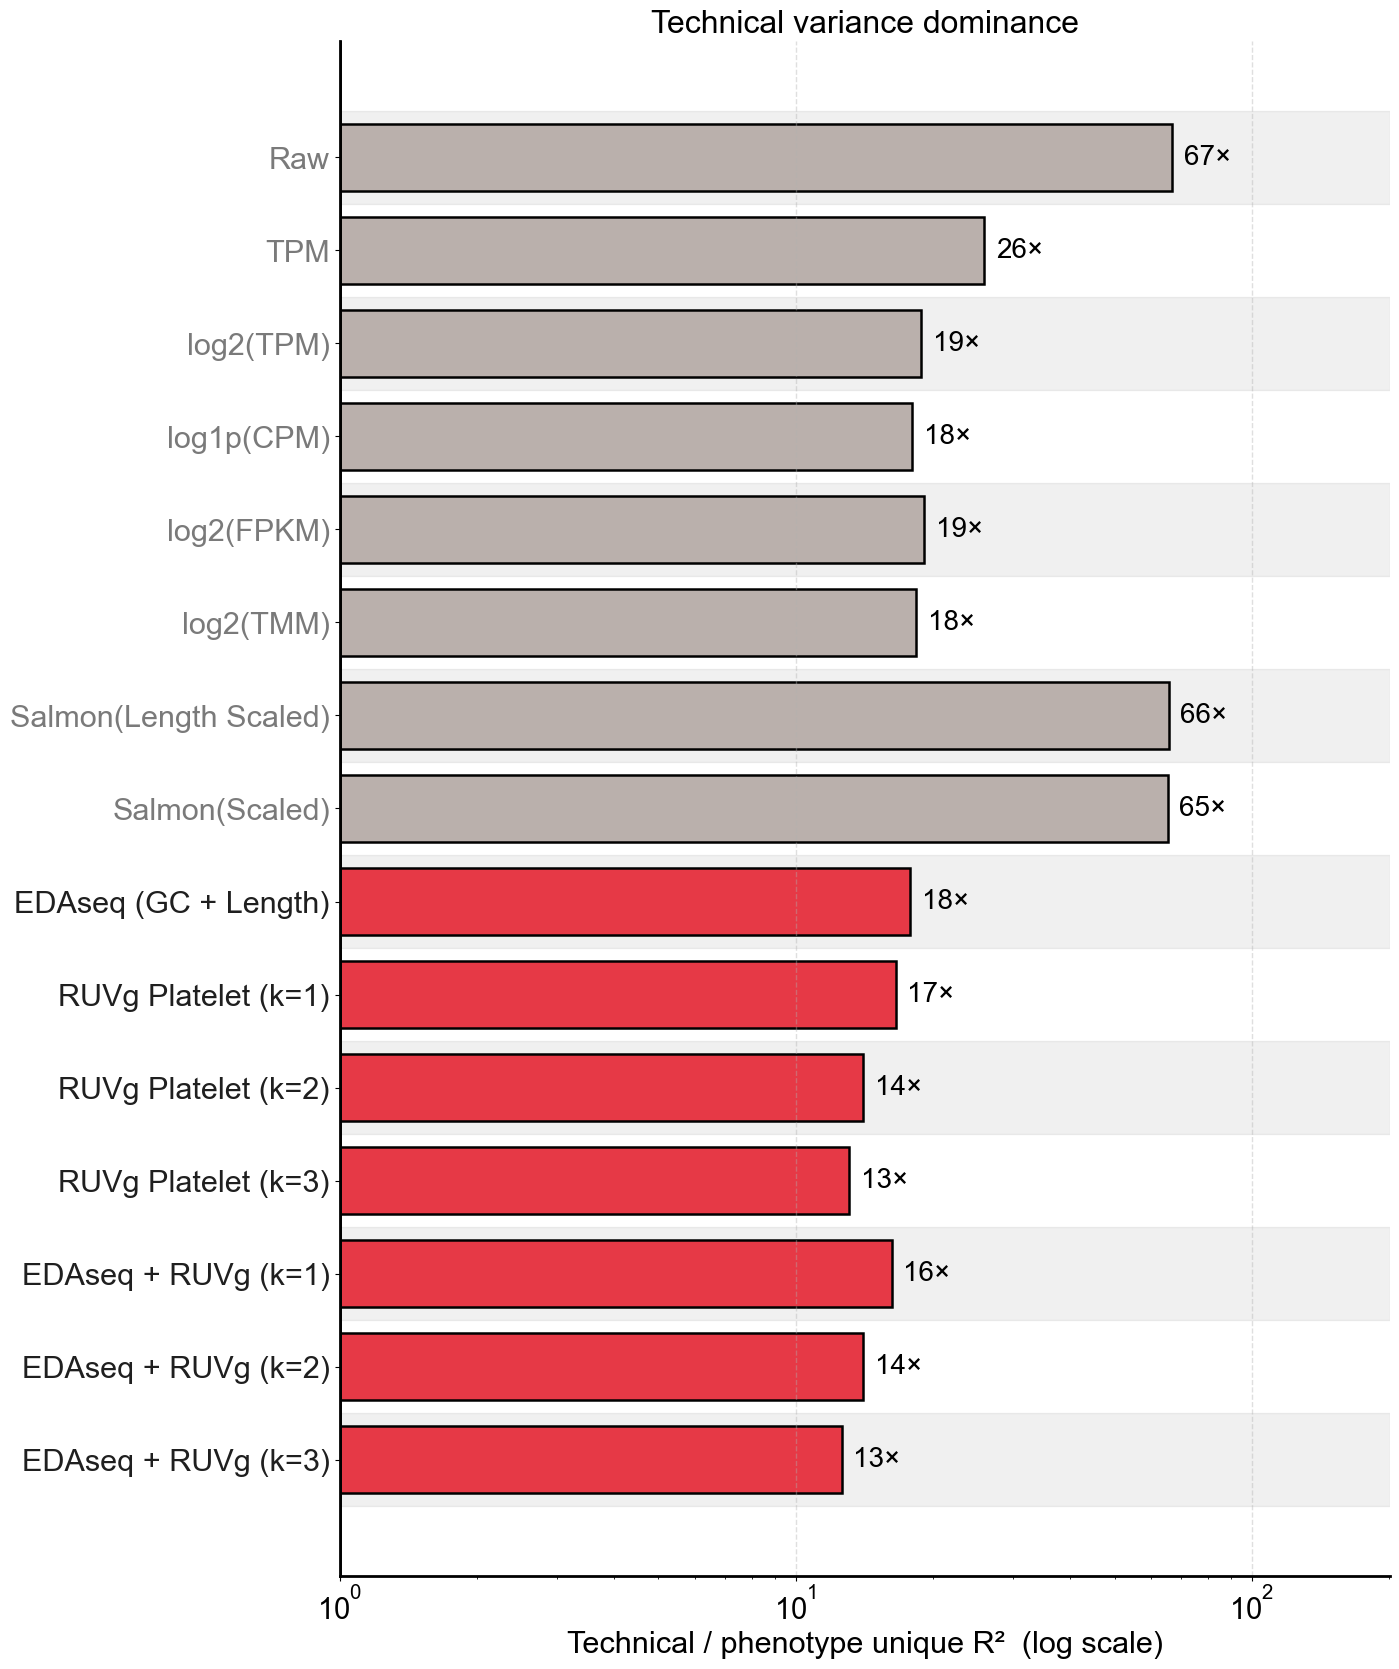

,pheno_unique_R2,total_unique_R2,pheno_share,fold_technical
Layer,,,,
Raw,0.0042,0.2854,0.0147,66.7970
TPM,0.0066,0.1771,0.0372,25.9059
log2(TPM),0.0037,0.0725,0.0504,18.8324
log1p(CPM),0.0040,0.0766,0.0526,17.9987
log2(FPKM),0.0035,0.0712,0.0497,19.1078
log2(TMM),0.0037,0.0726,0.0516,18.3768
Salmon(Length Scaled),0.0043,0.2835,0.0150,65.6819
Salmon(Scaled),0.0040,0.2648,0.0151,65.4261
EDAseq (GC + Length),0.0037,0.0690,0.0531,17.8402


In [16]:
unique_summary = plot_normalization_unique_r2_summary(
    str(UNIQUE_CACHE),
    save_path=str(RDA_DIR / "rda_normalization_unique_r2_summary.png"),
)
unique_summary.round(4)


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

obs_rda = adata.obs[~adata.obs["Author"].isin(EXCLUDE_FROM_PHENOTYPE_ANALYSIS)].copy()

stats_results = []
valid_batches = []
for batch_name, group in obs_rda.groupby('Batch_ID'):
    pheno_counts = group['Phenotype_Processed'].dropna().value_counts()
    valid_phenos = pheno_counts[pheno_counts >= 3].index.tolist()
    if len(valid_phenos) >= 2:
        valid_batches.append((batch_name, valid_phenos))
if not valid_batches:
    print("[Result] No multi-phenotype batches found for statistical testing.")

for batch_name, valid_phenos in valid_batches:
    df_batch = obs_rda[(obs_rda['Batch_ID'] == batch_name) & 
                       (obs_rda['Phenotype_Processed'].isin(valid_phenos))]
    
    for bias in bias_metrics:
        if bias not in df_batch.columns:
            continue
        try: 
            groups = [df_batch[df_batch['Phenotype_Processed'] == p][bias].dropna().values for p in valid_phenos]        
            if all(len(g) > 0 for g in groups):
                stat, p_val = kruskal(*groups)
                stats_results.append({'Batch': batch_name, 'Bias': bias, 'p_value': p_val})
            else:
                stats_results.append({'Batch': batch_name, 'Bias': bias, 'p_value': np.nan})
        except Exception:
            stats_results.append({'Batch': batch_name, 'Bias': bias, 'p_value': np.nan})

df_summary = pd.DataFrame(stats_results)
valid_mask = df_summary['p_value'].notna()
df_summary['padj_FDR'] = np.nan
if valid_mask.sum() > 0:
    _, pvals_corrected, _, _ = multipletests(
        df_summary.loc[valid_mask, 'p_value'], 
        alpha=0.05, 
        method='fdr_bh')
    df_summary.loc[valid_mask, 'padj_FDR'] = pvals_corrected

In [13]:
custom_x_order = [
    'Sample Volume (mL)', 
    'Total Centrifugation Force (g)',
    'log(Total Reads)', 
    'Spliced Reads (%)', 
    'gDNA Contamination (Intron/Exon)', 
    'rRNA Fraction', 
    'Platelet Score', 
    'GC Bias', 
    'Gene Length Bias', 
    "RNA Degradation (3' Bias)", 
    'NG80', 
    'NP80', 
    '(NP80/NG80)'
]
df_pivot = df_summary.pivot(index='Batch', columns='Bias', values='padj_FDR')
df_pivot = df_pivot.reindex(columns=custom_x_order)

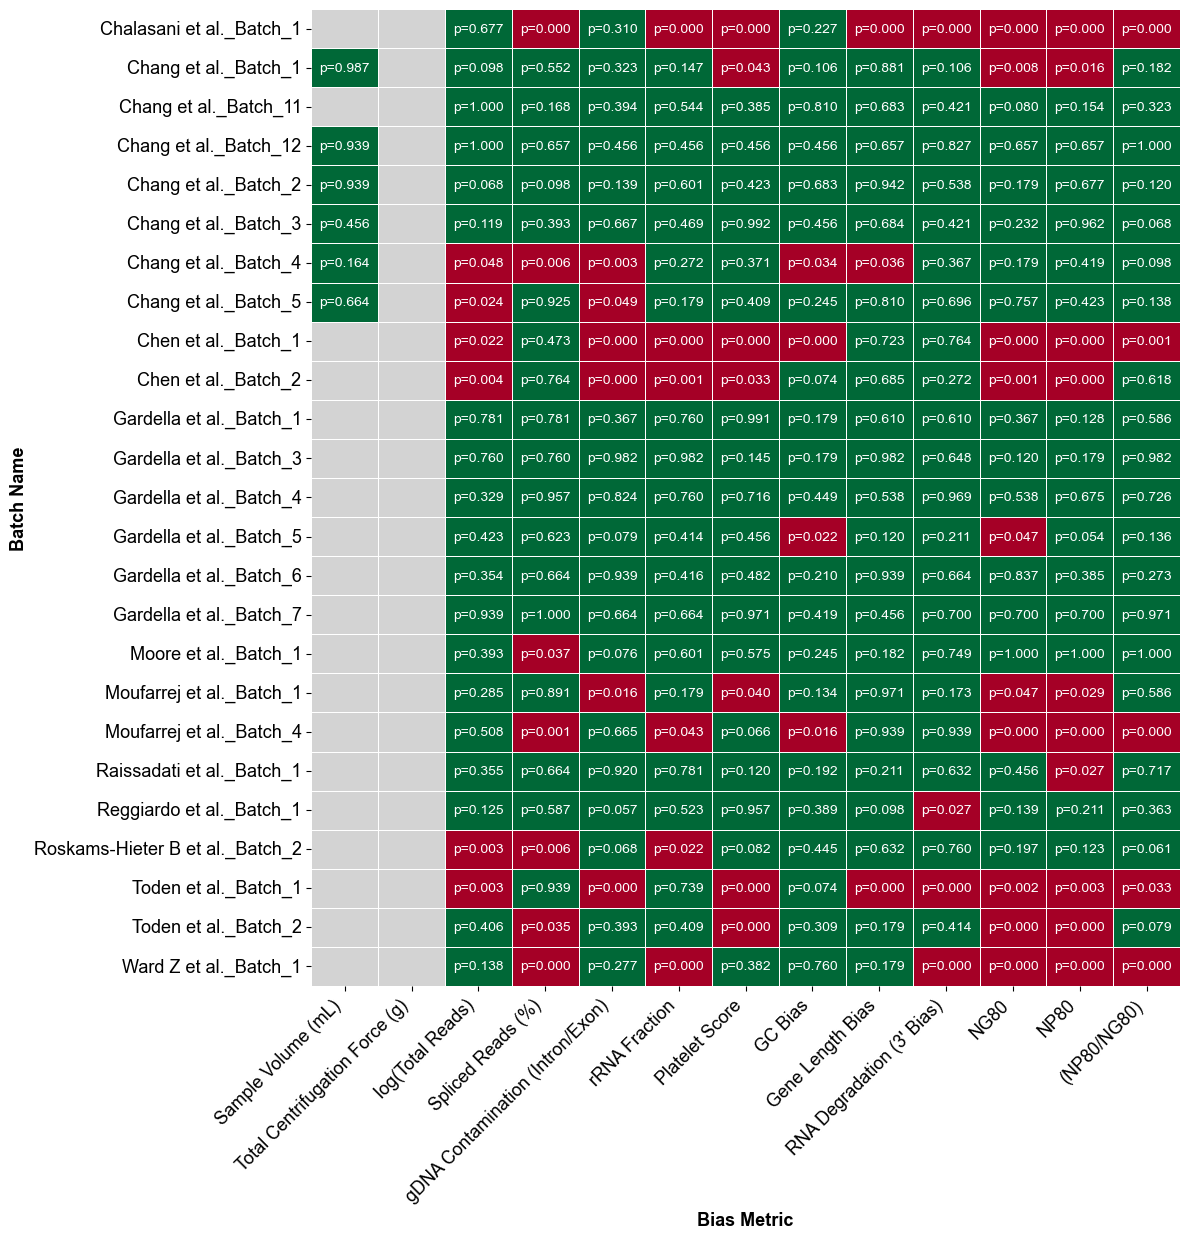

In [14]:
plt.figure(figsize=(min(12, len(bias_metrics) * 1.5), max(4, len(valid_batches) * 0.5)))
heatmap_data = (df_pivot >= 0.05).astype(float)
mask = df_pivot.isna()
annot_data = df_pivot.apply(lambda col: col.map(lambda x: f"p={x:.3f}" if pd.notna(x) else "N/A"))

ax = sns.heatmap(
    heatmap_data, 
    annot=annot_data, 
    fmt="", 
    cmap='RdYlGn', 
    cbar=False, 
    linewidths=0.5, 
    mask=mask,              
)
ax.set_facecolor('lightgray')
plt.xlabel("Bias Metric", fontweight='bold')
plt.ylabel("Batch Name", fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig("./Analysis_Results/RDA/phenotype_bias_confounding_test.png", bbox_inches='tight')
plt.show()


--- [Analysis] HC Cohort Partial RDA ---


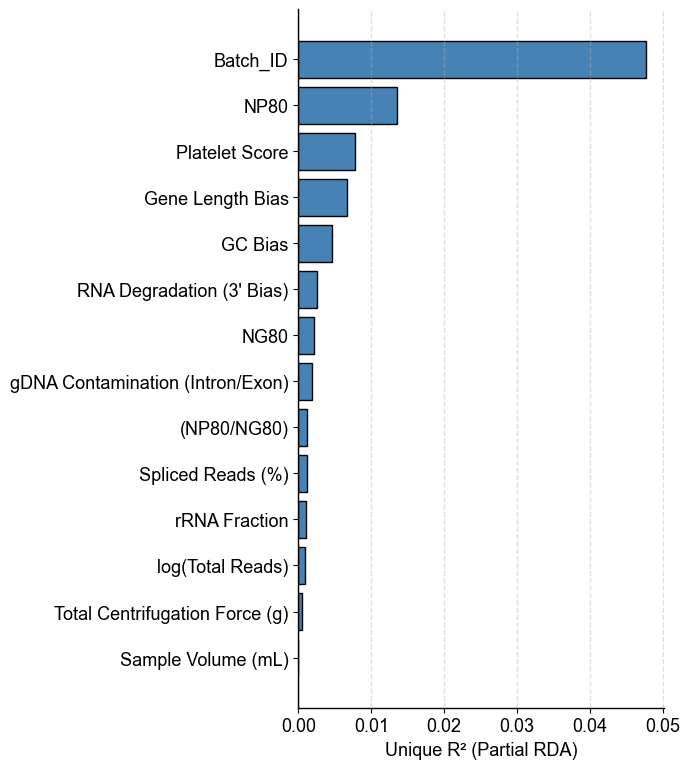

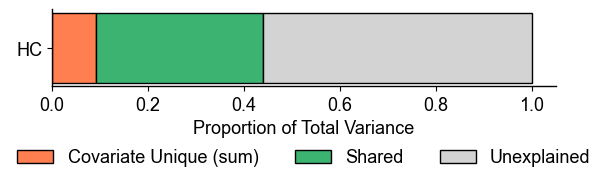

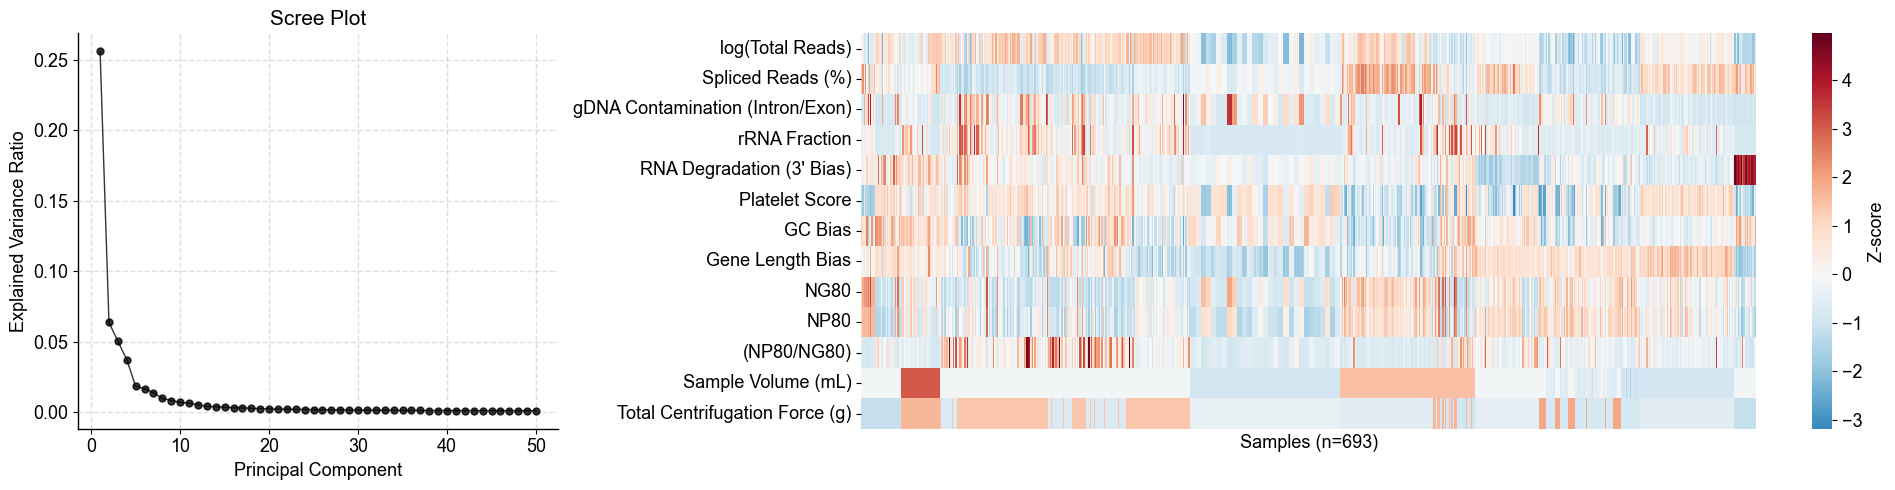

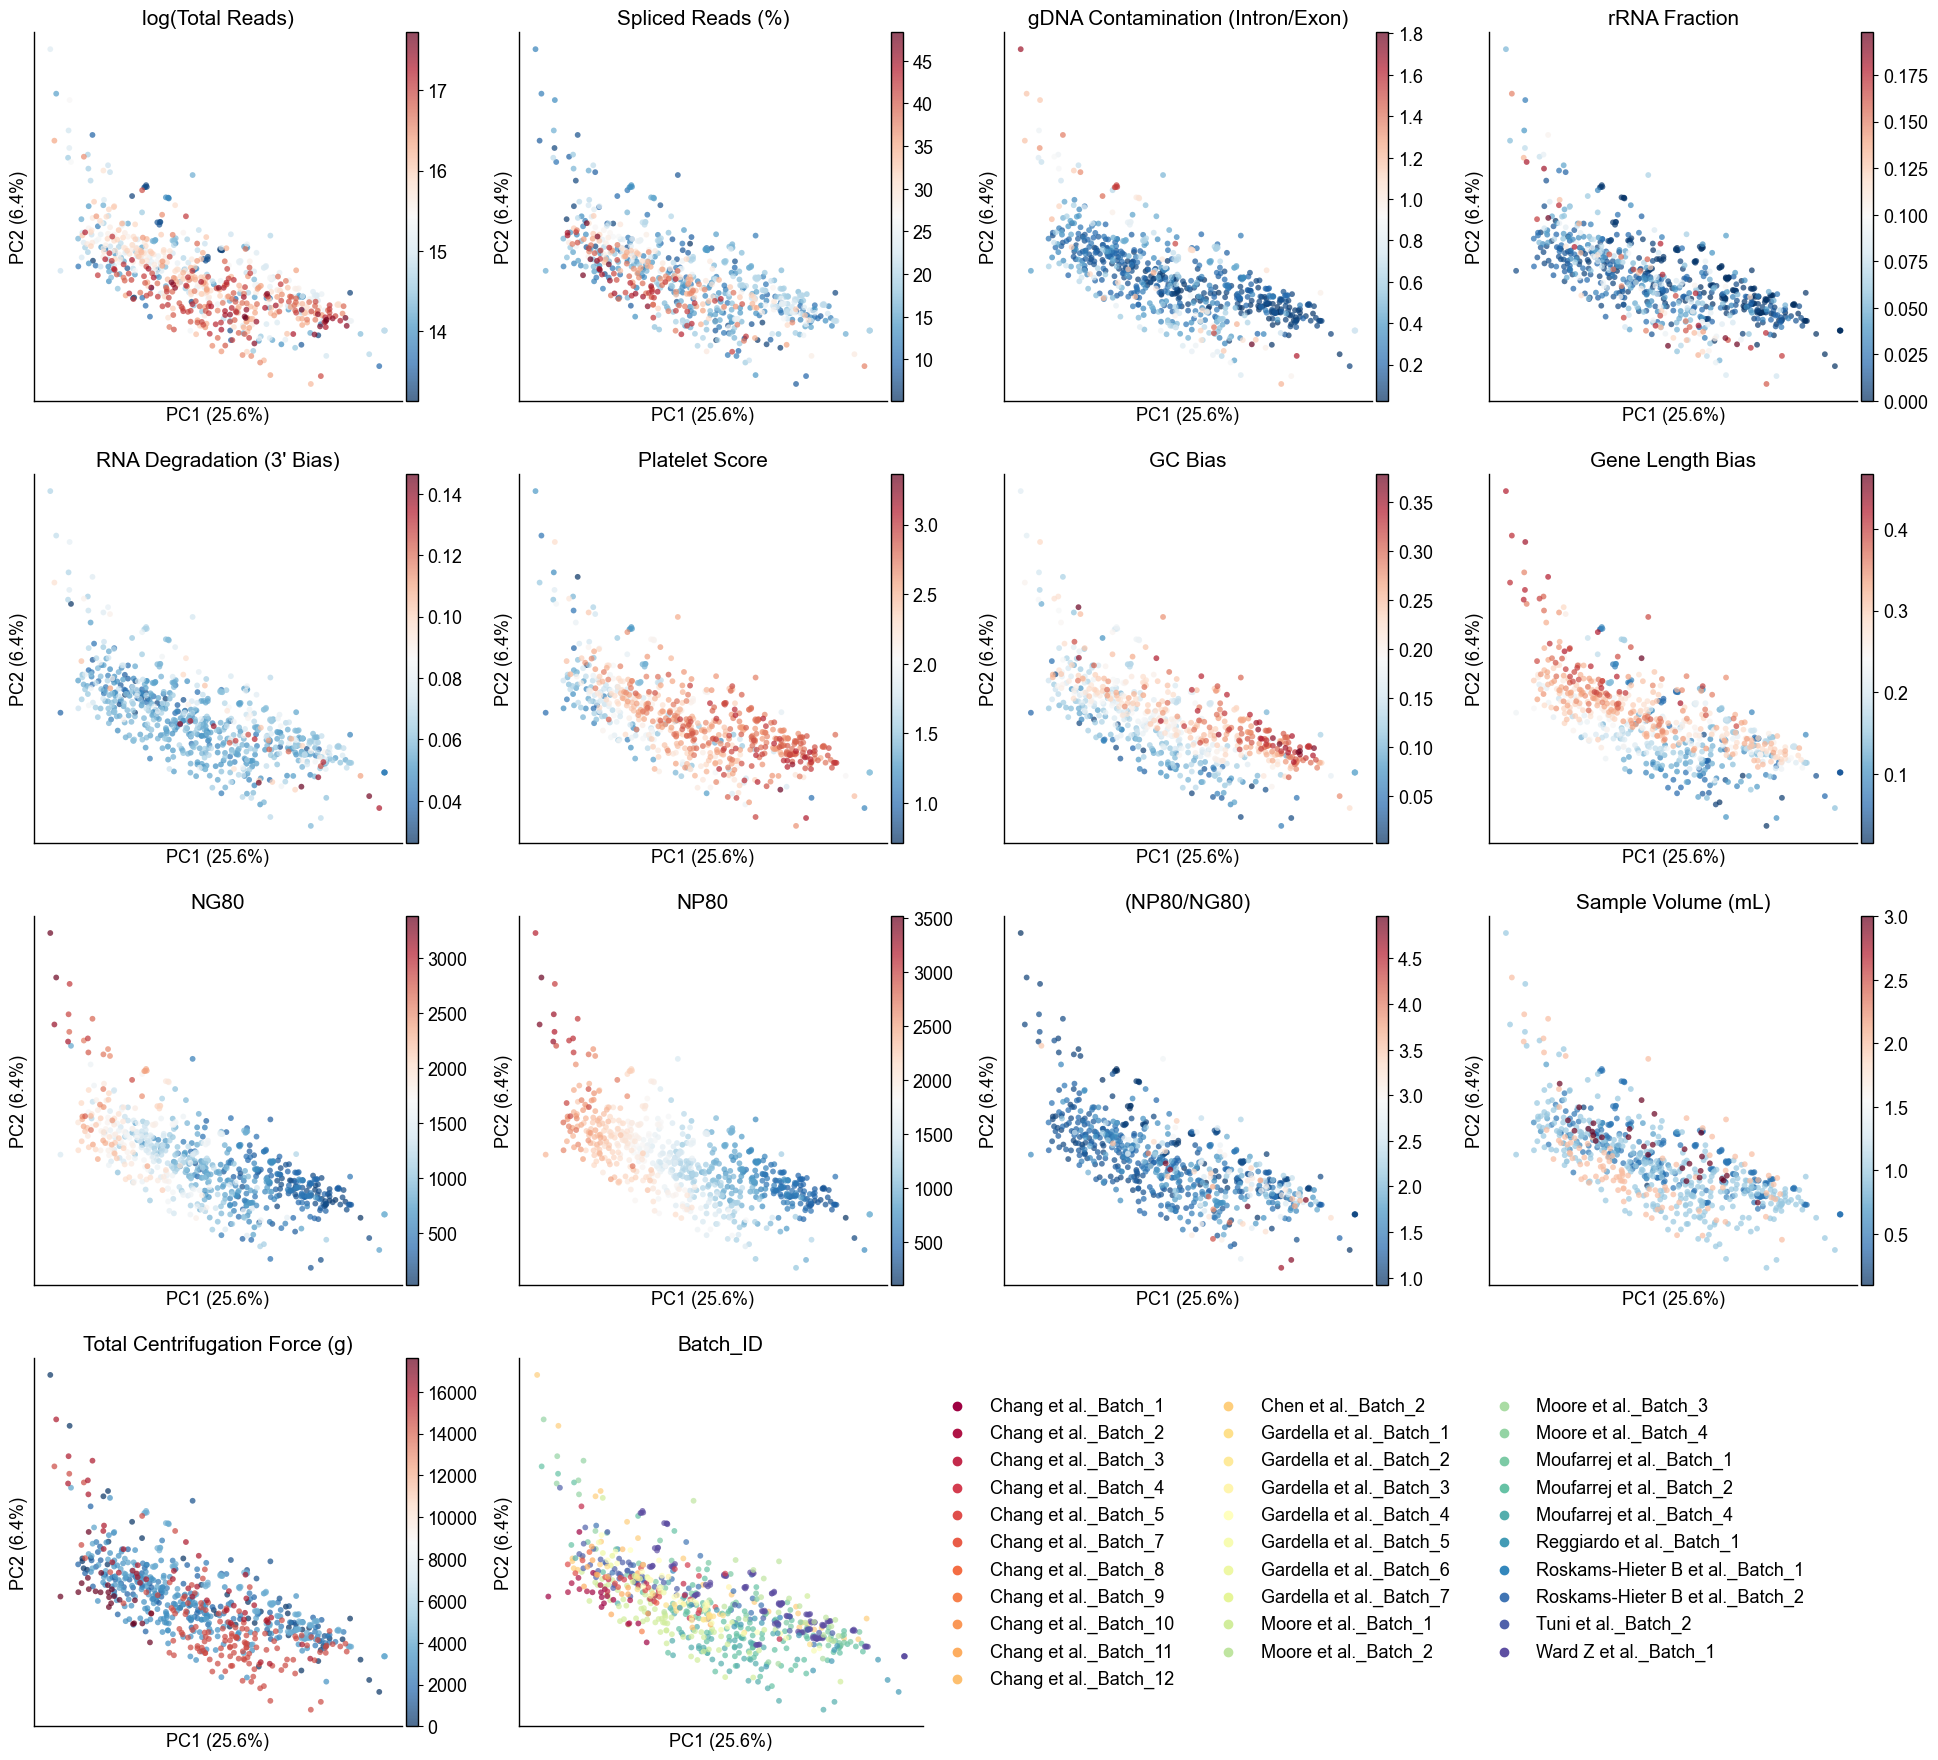

In [15]:
hc_vars = [v for v in rda_vars if v not in ['Phenotype_Processed']]
hc_results = pipeline_rda.analyze_hc_partial_rda(
    vars=hc_vars,
    batch_col='Batch_ID',
    hc_label='Healthy Control',
    phenotype_col='Phenotype_Processed',
    use_hvg=False,
    layer='CPM_log1p',
    save_path=None  # was "./Analysis_Results/RDA/HC/hc_partial_rda_results.png"
)

adata_tmp = adata[adata.obs['library_selection'] != 'Whole-Exome Capture'].copy()
plot_hc_variance_and_heatmap(
    adata_tmp,
    bias_metrics=combined_metrics,
    n_pcs=50,
    save_path=None  # was "./Analysis_Results/RDA/HC/hc_variance_and_heatmap.png"
)

plot_hc_pca_grid(
    adata_tmp,
    plot_vars=combined_metrics + ['Batch_ID'],
    save_path=None  # was "./Analysis_Results/RDA/HC/hc_pca_grid.png"
)